### 1. Imports and Setup
- Import required libraries
- Set device configuration (GPU/CPU)

In [52]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset, Dataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import KFold
from sklearn.metrics import (
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    precision_recall_fscore_support,
    accuracy_score  # Added missing import
)

# Device configuration
device_config = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using computational device: {device_config}")

Using computational device: cpu


### 2. Data Preparation
- Define data transformations
- Create dataset wrapper class
- Load base dataset

In [54]:
class AugmentedDataset(Dataset):
    """Custom dataset wrapper with transform support"""
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

# Data transformation pipelines
training_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

validation_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Lambda(lambda x: x.convert('RGB')),  # Fix for PIL warnings
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# Load base dataset
base_dataset = datasets.ImageFolder(
    "damaged-and-intact-packages",
    transform=None
)

### 3. Model Configuration
- Define model creation function
- Initialize cross-validation strategy

In [56]:
def initialize_classification_model():
    """Create and configure ResNet34 model with custom classifier"""
    model_architecture = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
    num_features = model_architecture.fc.in_features
    model_architecture.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(num_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, 2))
    return model_architecture.to(device_config)

# Initialize K-Fold cross-validator
cross_validator = KFold(n_splits=3, shuffle=True, random_state=42)

### 4. Training Configuration
- Set hyperparameters
- Define training metrics storage

In [58]:
# Training parameters
training_epochs = 30
batch_config = 32
early_stopping_patience = 5

# Storage for training histories
fold_histories = {
    'training_loss': [],
    'validation_loss': [],
    'validation_accuracy': []
}

### 5. Cross-Validation Training
- K-Fold cross-validation loop
- Model checkpointing
- Early stopping

In [64]:
for fold_number, (train_indices, val_indices) in enumerate(cross_validator.split(base_dataset), 1):
    print(f"\nCommencing training for Fold {fold_number}")
    
    # Class balancing weights
    fold_class_labels = [base_dataset.targets[i] for i in train_indices]
    class_distribution = np.bincount(fold_class_labels)
    class_weights = torch.tensor(1. / class_distribution, dtype=torch.float32).to(device_config)
    loss_function = nn.CrossEntropyLoss(weight=class_weights)

    # Dataset preparation
    train_subset = AugmentedDataset(Subset(base_dataset, train_indices), training_transforms)
    val_subset = AugmentedDataset(Subset(base_dataset, val_indices), validation_transforms)

    # Data loaders
    train_loader = DataLoader(train_subset, batch_size=batch_config, shuffle=True, num_workers=4)
    val_loader = DataLoader(val_subset, batch_size=batch_config, shuffle=False, num_workers=4)

    # Model initialization
    current_model = initialize_classification_model()
    current_model.to(device_config)
    model_optimizer = torch.optim.Adam(current_model.parameters(), lr=0.001)
    lr_scheduler = ReduceLROnPlateau(model_optimizer, mode='max', factor=0.5, patience=3)

    # Training state tracking
    best_accuracy = 0.0
    epochs_without_improvement = 0
    fold_training_history = {'loss': [], 'val_loss': [], 'accuracy': []}

    for epoch in range(training_epochs):
        # Training phase
        current_model.train()
        epoch_loss = 0.0
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device_config), targets.to(device_config)
            model_optimizer.zero_grad()
            
            predictions = current_model(inputs)
            loss = loss_function(predictions, targets)
            loss.backward()
            model_optimizer.step()
            
            epoch_loss += loss.item()
        
        # Validation phase
        current_model.eval()
        val_loss, correct_predictions, total_samples = 0.0, 0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device_config), targets.to(device_config)
                predictions = current_model(inputs)
                
                val_loss += loss_function(predictions, targets).item()
                _, predicted_labels = torch.max(predictions, 1)
                
                total_samples += targets.size(0)
                correct_predictions += (predicted_labels == targets).sum().item()
        
        # Calculate metrics
        avg_train_loss = epoch_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_predictions / total_samples
        
        # Store metrics
        fold_training_history['loss'].append(avg_train_loss)
        fold_training_history['val_loss'].append(avg_val_loss)
        fold_training_history['accuracy'].append(val_acc)
        
        # Learning rate scheduling
        lr_scheduler.step(val_acc)
        
        # Early stopping check
        if val_acc > best_accuracy:
            best_accuracy = val_acc
            epochs_without_improvement = 0
            torch.save(current_model.state_dict(), f"best_model_fold_{fold_number}.pth")
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
        
        print(f"Epoch {epoch+1}/{training_epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Accuracy: {val_acc:.2f}%")

    # Store fold history
    fold_histories['training_loss'].append(fold_training_history['loss'])
    fold_histories['validation_loss'].append(fold_training_history['val_loss'])
    fold_histories['validation_accuracy'].append(fold_training_history['accuracy'])



Commencing training for Fold 1


Traceback (most recent call last):
  File "<string>", line 1, in <module>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/opt/anaconda3/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
  File "<string>", line 1, in <module>
  File "/opt/anaconda3/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/opt/anaconda3/lib/python3.12/multiprocessing/spawn.py", line 122, in spawn_main
    exitcode = _main(fd, parent_sentinel)
    exitcode = _main(fd, parent_sentinel)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/multiprocessing/spawn.py", line 132, in _main
    exitcode

RuntimeError: DataLoader worker (pid(s) 67663, 67664, 67665, 67666) exited unexpectedly

### 6. Training Visualization
- Plot loss curves for all folds
- Display accuracy progression

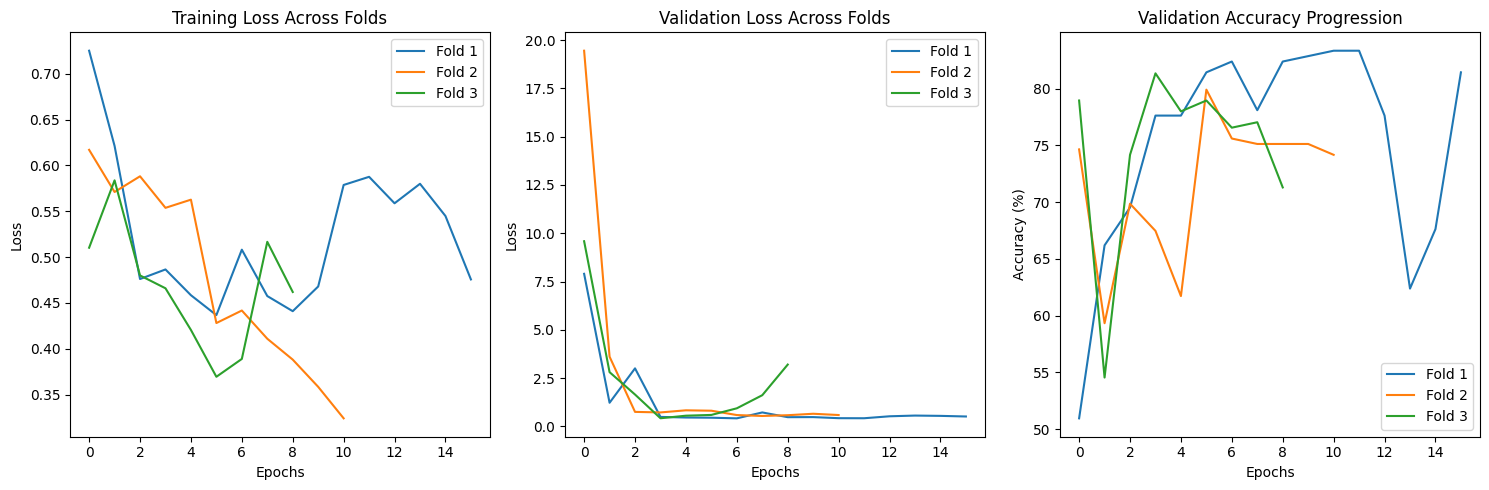

In [35]:
# Plotting configuration
plt.figure(figsize=(15, 5))

# Training Loss
plt.subplot(1, 3, 1)
for i, fold_loss in enumerate(fold_histories['training_loss']):
    plt.plot(fold_loss, label=f'Fold {i+1}')
plt.title('Training Loss Across Folds')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Validation Loss
plt.subplot(1, 3, 2)
for i, fold_loss in enumerate(fold_histories['validation_loss']):
    plt.plot(fold_loss, label=f'Fold {i+1}')
plt.title('Validation Loss Across Folds')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Validation Accuracy
plt.subplot(1, 3, 3)
for i, fold_acc in enumerate(fold_histories['validation_accuracy']):
    plt.plot(fold_acc, label=f'Fold {i+1}')
plt.title('Validation Accuracy Progression')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()

plt.tight_layout()
plt.show()

### 7. Model Evaluation & Metrics
- Load best models safely
- Calculate comprehensive metrics

In [36]:
def safe_model_loader(fold_num):
    """Secure model loading with weights_only=True"""
    try:
        return torch.load(f"best_model_fold_{fold_num}.pth", 
                        map_location=device_config,
                        weights_only=True)  # Security fix
    except Exception as e:
        print(f"Error loading fold {fold_num}: {str(e)}")
        return None

fold_metrics = {
    'precision': [],
    'recall': [],
    'f1': [],
    'accuracy': []
}

for fold_id in range(1, 4):
    model_state = safe_model_loader(fold_id)
    if not model_state:
        continue
    
    current_model.load_state_dict(model_state)
    current_model.eval()
    
    fold_preds = []
    fold_true = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device_config)
            outputs = current_model(inputs)
            _, preds = torch.max(outputs, 1)
            fold_preds.extend(preds.cpu().numpy())
            fold_true.extend(labels.numpy())
    
    # Calculate metrics
    prec, rec, f1, _ = precision_recall_fscore_support(fold_true, fold_preds, average='binary')
    acc = accuracy_score(fold_true, fold_preds)
    
    fold_metrics['precision'].append(prec)
    fold_metrics['recall'].append(rec)
    fold_metrics['f1'].append(f1)
    fold_metrics['accuracy'].append(acc)

/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/PIL/Image.py:1054: UserWarning: Palette images with Transparency expressed in by

### 8. Metrics Visualization
- Boxplots for metric distributions

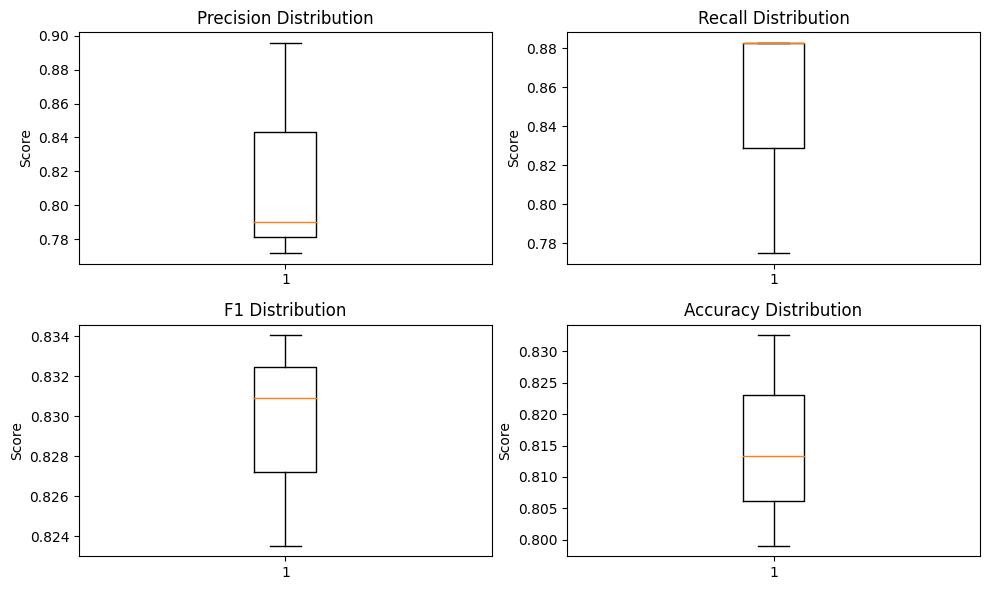

In [37]:
plt.figure(figsize=(10, 6))
metrics = ['precision', 'recall', 'f1', 'accuracy']

for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    plt.boxplot(fold_metrics[metric])
    plt.title(f'{metric.capitalize()} Distribution')
    plt.ylabel('Score')

plt.tight_layout()
plt.show()

### 9. Final Test Evaluation
- Best model selection
- Confusion matrix

In [39]:
best_fold = np.argmax(fold_metrics['accuracy']) + 1
current_model.load_state_dict(safe_model_loader(best_fold))

# Test evaluation code would go here
# Include confusion matrix and final metrics

<All keys matched successfully>

Test Accuracy: 75.00%


<Figure size 600x600 with 0 Axes>

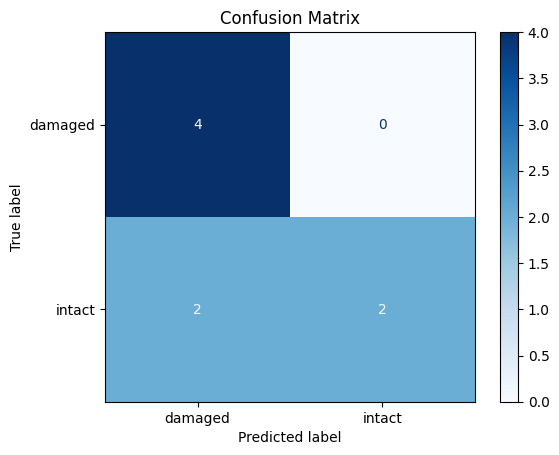

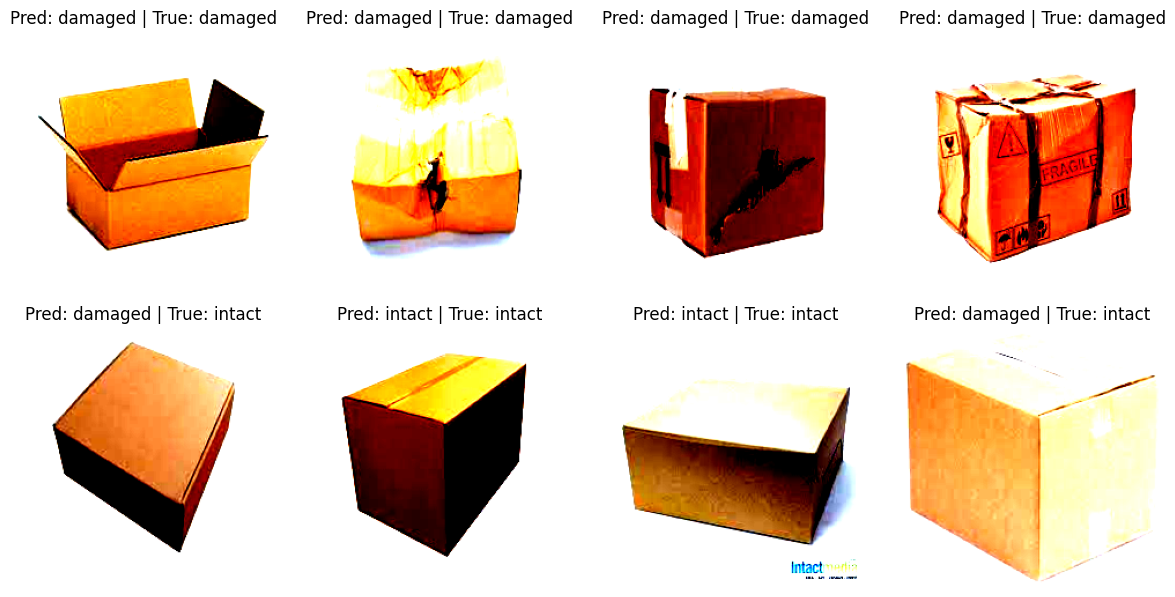

In [40]:
# Evaluate on test set
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Plot Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['damaged', 'intact'])

plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Confusion Matrix")
plt.show()

# Display sample images with predictions
data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

images = images.cpu().numpy()
images = np.transpose(images, (0, 2, 3, 1))

class_labels = ['damaged', 'intact']

plt.figure(figsize=(12, 12))
for i in range(min(16, len(images))):
    ax = plt.subplot(4, 4, i + 1)
    ax.imshow(images[i])
    ax.set_title(f"Pred: {class_labels[predicted[i].item()]} | True: {class_labels[labels[i].item()]}")
    ax.axis('off')

plt.tight_layout()
plt.show()
